# Combinatorial Black-Box Optimization: Integrating Bayesian Surrogates with QUBO Formulations

Welcome to this interactive exploration of Black-Box Optimization. In many real-world engineering and scientific scenarios, from drug discovery to circuit design, we are faced with a "Black Box", a system where we can see the inputs and the output, but the internal logic is hidden and incredibly complex. In industry, querying a "Black Box" (e.g. running a physical crash test or a high-fidelity simulation) is usually expensive and time-consuming. We use surrogate models, represented as simple functions, to build a mathematical map of the problem for efficient search.

## Objectives
In this notebook, you will explore:
- The Concept of the Black-Box Function: Understand how non-linear interactions create "rugged" landscapes that make finding an global maximum difficult.

- The Strategy of Surrogate Model-Based Optimization: Learn how to build and refine a surrogate model of a hidden system. You will explore the iterative loop of using past observations to predict unknown landscapes and balancing *Exploration* (searching uncertain areas) with *Exploitation* (targeting predicted peaks) to find the optimum with limited trials.

- The Connection to Quantum Annealing: Discover how a surrogate model's predictions can be translated into a Quadratic Unconstrained Binary Optimization (QUBO) format that allows the D-Wave Quantum Annealer to find optimal solutions.

# 1. Introduction: The Mystery Circuit
We use a "Mystery Circuit" model as an example of a Black-Box Function. In this scenario, you can control a set of switches and see the resulting output voltage, but the internal wiring and logic are hidden from view. While the search space is vast, your goal is simple: *find the switch configuration that maximizes the output to 10V.*

To make this challenging, the circuit logic is designed so that switches interact with one another. This means flipping one switch might change how another switch behaves, creating a "rugged" landscape of values that is difficult to navigate by simple guessing.

## 1.1 Import packages and load the "Mystery Circuit"
First, let's import the necessary Python packages and load the core logic for the "Mystery Circuit" demonstration.

In [ ]:
import numpy as np
from itertools import combinations, product

import ipywidgets as widgets
from IPython.display import display, clear_output

import matplotlib.pyplot as plt

import base64  # to decode obfuscated snippet

In [ ]:
# @title Black-box function
_logic = "Y2xhc3MgTXlzdGVyeUNpcmN1aXQ6CiAgICBkZWYgX19pbml0X18oc2VsZiwgbj0xMCwgaz0yLCBzZWVkPU5vbmUpOgogICAgICAgIHNlbGYubiA9IG4KICAgICAgICBzZWxmLmsgPSBrCiAgICAgICAgc2VsZi5fcm5nID0gbnAucmFuZG9tLmRlZmF1bHRfcm5nKHNlZWQ9c2VlZCkKICAgICAgICBzZWxmLl9yYXdfbWluID0gMTAwMAoKICAgICAgICAjIDEuIEdlbmVyYXRlIHJhbmRvbSB0YWJsZXMKICAgICAgICBzZWxmLnRhYmxlcyA9IFtdCiAgICAgICAgZm9yIGkgaW4gcmFuZ2Uobik6CiAgICAgICAgICAgIHRhYmxlID0ge2JpdHM6IHNlbGYuX3JuZy51bmlmb3JtKDAsIDEpIGZvciBiaXRzIGluIHByb2R1Y3QoWzAsIDFdLCByZXBlYXQ9aysxKX0KICAgICAgICAgICAgc2VsZi50YWJsZXMuYXBwZW5kKHRhYmxlKQoKICAgICAgICAjIDIuIEJydXRlIGZvcmNlIHRvIGZpbmQgbWF4IGFuZCB0aGUgYmVzdCBjb25maWd1cmF0aW9uCiAgICAgICAgc2VsZi5fcmF3X21heCwgc2VsZi5iZXN0X2NvbmZpZyA9IHNlbGYuX2ZpbmRfZ2xvYmFsX29wdGltdW0oKQoKICAgIGRlZiBfZmluZF9nbG9iYWxfb3B0aW11bShzZWxmKToKICAgICAgICBtYXhfc2NvcmUgPSAtMQogICAgICAgIG1pbl9zY29yZSA9IDEwMDAKICAgICAgICBiZXN0X2MgPSBOb25lCgogICAgICAgIGZvciBjb25maWcgaW4gcHJvZHVjdChbMCwgMV0sIHJlcGVhdD1zZWxmLm4pOgogICAgICAgICAgICBjdXJyZW50X3Njb3JlID0gc2VsZi5fY2FsY3VsYXRlX3Jhdyhjb25maWcpCiAgICAgICAgICAgIGlmIGN1cnJlbnRfc2NvcmUgPiBtYXhfc2NvcmU6CiAgICAgICAgICAgICAgICBtYXhfc2NvcmUgPSBjdXJyZW50X3Njb3JlCiAgICAgICAgICAgICAgICBiZXN0X2MgPSBjb25maWcKICAgICAgICAgICAgaWYgY3VycmVudF9zY29yZSA8IG1pbl9zY29yZToKICAgICAgICAgICAgICAgIG1pbl9zY29yZSA9IGN1cnJlbnRfc2NvcmUKCiAgICAgICAgc2VsZi5fcmF3X21pbiA9IG1pbl9zY29yZQogICAgICAgICMgUmV0dXJuIHRoZSBtYXggdmFsdWUgYW5kIHRoZSBjb25maWcgYXMgYSByZWFkYWJsZSBzdHJpbmcKICAgICAgICByZXR1cm4gbWF4X3Njb3JlLCAiIi5qb2luKG1hcChzdHIsIGJlc3RfYykpCgogICAgZGVmIF9jYWxjdWxhdGVfcmF3KHNlbGYsIHN3aXRjaGVzKToKICAgICAgICBzY29yZSA9IDAKICAgICAgICBmb3IgaSBpbiByYW5nZShzZWxmLm4pOgogICAgICAgICAgICBzdWJfY29uZmlnID0gdHVwbGUoc3dpdGNoZXNbKGkgKyBqKSAlIHNlbGYubl0gZm9yIGogaW4gcmFuZ2Uoc2VsZi5rICsgMSkpCiAgICAgICAgICAgIHNjb3JlICs9IHNlbGYudGFibGVzW2ldW3N1Yl9jb25maWddCiAgICAgICAgcmV0dXJuIHNjb3JlCgogICAgZGVmIGdldF92b2x0YWdlKHNlbGYsIHN3aXRjaGVzKToKICAgICAgICByYXcgPSBzZWxmLl9jYWxjdWxhdGVfcmF3KHN3aXRjaGVzKQogICAgICAgIGJpYXMgPSBzZWxmLl9yYXdfbWluCiAgICAgICAgZmFjdG9yID0gc2VsZi5fcmF3X21heCAtIHNlbGYuX3Jhd19taW4KICAgICAgICByZXR1cm4gaW50KHJvdW5kKCgocmF3IC0gYmlhcykgLyBmYWN0b3IpICogMTAsIDIpKQ=="
exec(base64.b64decode(_logic))

## 1.2 Set the circuit parameters
Before we start optimization, we need to define three parameters that control the optimization problem:

- `n_switches` (Number of switches; set to 10): This defines our search space. Since each switch is binary (ON/OFF), there are $2^{10}=1024$ possible configurations.  
 *\*The black-box function runs a brute-force algorithm for scaling output. Avoid choosing a too large value (20+), or the notebook will hang up.*
- `K` (set to 1): This controls the complexity of the black-box function. See the section xx if you are interested in the function itself.
- `seed` (set to 42): We use a fixed seed to ensure that every learner starts with the same "Mystery Circuit."

In [ ]:
# Black-box parameters
n_switches = 10  # number of switches
K = 1            # parameter that controls the complexity of the black-box model
seed = 55        # seed for random number generator


# Initialize the game
my_circuit = MysteryCircuit(n=n_switches, k=K, seed=seed)
config_history = []
history_human = []

print(f"Mystery Circuit initialized with {n_switches} switches.")
print("Your goal is to reach 10 V.")

Mystery Circuit initialized with 10 switches.
Your goal is to reach 10 V.


## 1.3 Run cells for the interactive game UI

In [ ]:
# @title UI Elements
bulb_label = widgets.HTML(value="<h1 style='font-size: 60px; text-align: center;'>⚫</h1>")
voltage_bar = widgets.IntProgress(value=0, min=0, max=10, description='Voltage:', bar_style='info')
counter_label = widgets.HTML(value="<b>Trials: 0</b>")
history_box = widgets.Select(options=[], description='History:', layout={'height': '150px', 'width': '250px'})
status_text = widgets.Label(value="Find the 10 V configuration!")

switches = [widgets.ToggleButton(value=False, description=f'SW {i}', layout={'width': '80px'}) for i in range(n_switches)]

submit_btn = widgets.Button(description="Submit Configuration", button_style='primary', layout={'width': '200px'})

def on_submit(change):
    current_config = [1 if s.value else 0 for s in switches]
    voltage = my_circuit.get_voltage(current_config)
    iter = len(config_history)

    # Update Bulb Icon
    voltage_bar.value = int(voltage)
    icons = ["⚫", "🌑", "🌘", "🌗", "🌖", "🌕", "⭐", "🌟", "🔥", "⚡", "☀️"]
    bulb_label.value = f"<h1 style='font-size: 60px; text-align: center;'>{icons[int(voltage)]}</h1>"

    # Update UI
    config_str = "".join(map(str, current_config))
    # Add to history if it's a new personal best or just log the attempt
    entry = f"#{iter+1}: {voltage} V ({config_str})"
    config_history.insert(0, entry)
    counter_label.value = f"<b>Trials: {iter+1}</b>"
    history_box.options = config_history
    history_human.append((iter, voltage))

    if voltage == 10.0:
        status_text.value = f"🎉 OPTIMUM FOUND in {iter+1} trials!"
        voltage_bar.bar_style = 'success'

submit_btn.on_click(on_submit)

In [ ]:
# @title Layout
controls = widgets.GridBox(switches, layout=widgets.Layout(grid_template_columns="repeat(5, 90px)"))
stats_vbox = widgets.VBox([counter_label, history_box])
main_ui = widgets.HBox([
    widgets.VBox([bulb_label, voltage_bar, status_text, controls, submit_btn], layout={'width': '500px', 'align_items': 'center'}),
    stats_vbox
], layout={'border': '1px solid #ccc', 'padding': '10px'})

In [ ]:
# @title Helper function for visualizing output history
def optimization_visualizer(history, optimizer=""):
    # Plotting
    iters, volts = zip(*history)
    plt.figure(figsize=(10, 5))
    plt.step(iters, volts, where='post', color='#2ca02c', linewidth=2)
    plt.axhline(y=10, color='r', linestyle='--', label='Global Optimum (10V)')
    plt.title(f"{optimizer} for Mystery Circuit")
    plt.xlabel("Number of Queries (Trials)")
    plt.ylabel("Voltage")
    plt.ylim((0, 11))
    plt.grid(alpha=0.3)
    plt.legend()
    plt.show()

## 1.4 Play the Mystery Circuit game
Now it's time to test your intuition! Use the interface below to explore the hidden logic of the circuit.

Your goal is: Find the specific pattern of 10 switches that outputs exactly 10 V.

To evaluate the output, click the numbered buttons to flip switches ON (dark gray) or OFF (light gray). Then, click the "Submit Configuration" button to send your pattern to the circuit. Watch the "Voltage" meter and the history of trials on the right pane.

In [ ]:
display(main_ui)

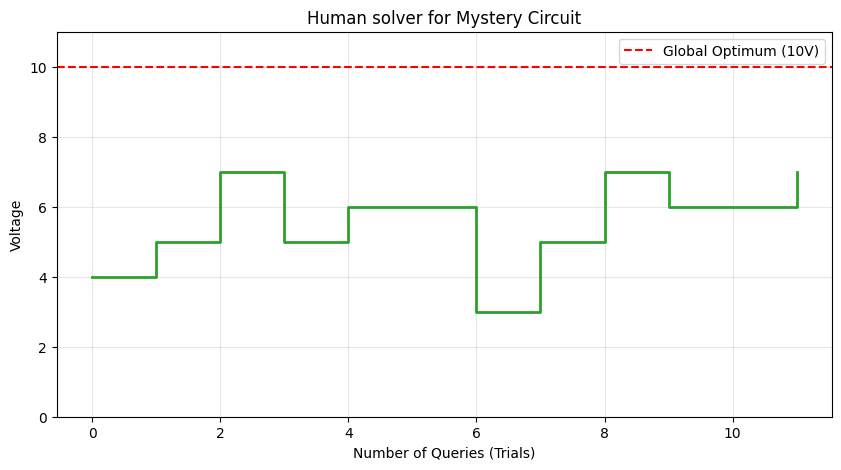

In [ ]:
optimization_visualizer(history_human, "Human solver")

# 2. Black-Box Optimization
In the "Mystery Circuit" game, you were dealing with a black-box function. This means you could see what you put in (switch settings) and what came out (voltage), but you couldn't see the internal math or wiring.

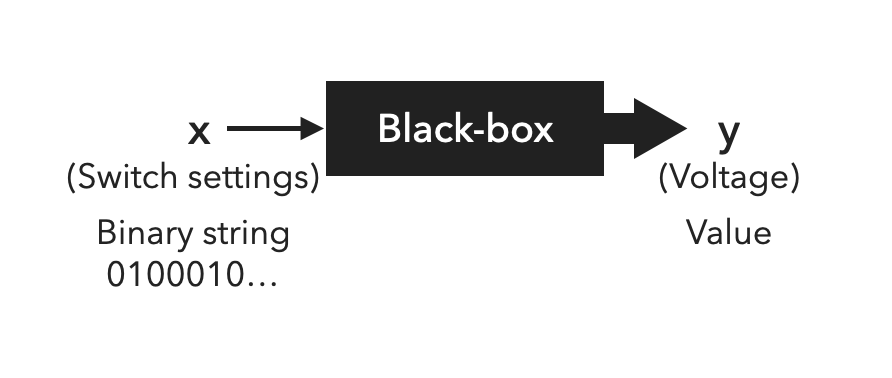


In many real-world scenarios, such as designing a new material, the underlying objective function is either unknown or too expensive to calculate analytically. We have to find the best configuration through trial and error. This process is called Black-Box Optimization (BBO). The goal is to find the maximum value (10 V) in as few attempts as possible, as each trial in the real world might be expensive or time-consuming.

## 2.1 Hill-climbing / Greedy strategy
The simplest strategy in black-box optimization is to evaluate a "neighbor" configuration and accept it if it improves the result. Here, a "neighbor" means a configuration where we flip only one bit at random.

In our example, the algorithm flips one switch and checks if the voltage is increased. Then, it saves the new configuration only if the performance improved. Let's see how this basic strategy performs on our circuit.

In [ ]:
# @title Hill Climbing
def hill_climbing_solver(circuit, iterations=100):
    # 1. Start with a random configuration
    current_config = [np.random.randint(0, 1) for _ in range(circuit.n)]
    current_voltage = circuit.get_voltage(current_config)

    history = [(0, current_voltage)]
    print(f"Starting Voltage: {current_voltage}V")

    for i in range(1, iterations + 1):
        # 2. Flip one random switch
        neighbor = list(current_config)
        idx = np.random.randint(0, circuit.n - 1)
        neighbor[idx] = 1 - neighbor[idx]

        # 3. Evaluate the neighbor (The Black-box query)
        neighbor_voltage = circuit.get_voltage(neighbor)

        # 4. Acceptance rule: Only move if it's an improvement
        if neighbor_voltage > current_voltage:
            current_config = neighbor
            current_voltage = neighbor_voltage
            print(f"Iteration {i}: New Best Found! {current_voltage}V")

        history.append((i, current_voltage))

        if current_voltage == 10.0:
            print(f"Global Optimum reached at iteration {i}!")
            break

    return current_config, history

Starting Voltage: 2V
Iteration 3: New Best Found! 3V
Iteration 12: New Best Found! 4V
Iteration 13: New Best Found! 5V
Iteration 17: New Best Found! 7V
Iteration 28: New Best Found! 8V


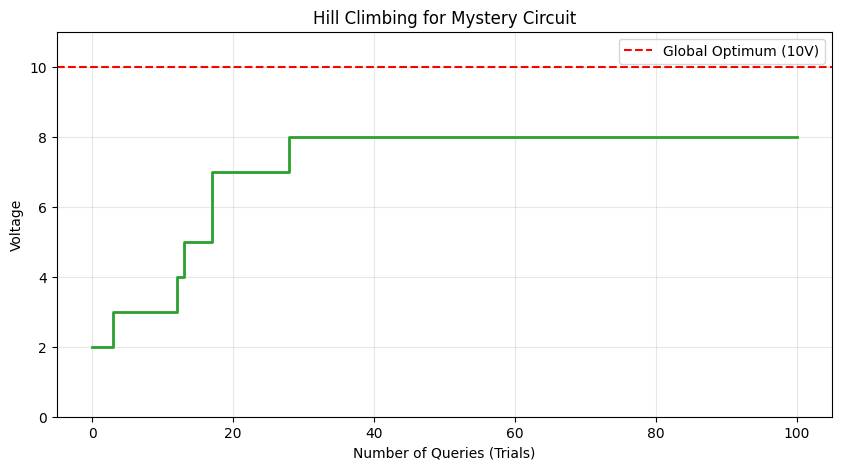

In [ ]:
_, history_hc = hill_climbing_solver(my_circuit)
optimization_visualizer(history_hc, "Hill Climbing")

**The limitation of hill climbing**

As the results above show, the hill-climbing strategy eventually stops improving even if it hasn't reached 10 V. This happens because the algorithm has reached a local optimum. Because the Hill-Climbing strategy only accepts changes that result in an immediate increase, it cannot move across a valley of lower voltage to find the higher peak on the other side in a complex energy landscape.

To find the global maximum, we need a strategy that can occasionally accept "bad" moves to explore the landscape more broadly. We need a way to "hop" over the valleys to escape local traps and discover the global peak.

## 2.2 Simulated annealing
By introducing probabilistic behaviour, simulated annealing solves the problem that the hill-climbing strategy fails to find the global optimum in a "rugged" landscape.

We introduce a temperature parameter $T$ to induce "thermal" fluctuation. When the temperature is high, the algorithm frequently accepts configurations that worsen the results; when the temperature is low, it behaves like a hill-climbing strategy. By starting with a high temperature and slowly "cooling" it down, we give the algorithm the chance to hop over valleys and find the global maximum (10 V).

In [ ]:
# @title Simulated Annealing
def simulated_annealing(circuit, initial_temp=1.0, cooling_rate=0.99, iterations=500):
    # 1. Start with a random configuration
    current_config = [np.random.randint(0, 1) for _ in range(circuit.n)]
    current_volts = circuit.get_voltage(current_config)

    best_config = list(current_config)
    best_volts = current_volts

    temp = initial_temp
    history = [(0, current_volts)]

    for i in range(1, iterations + 1):
        # 2. Flip one random switch
        neighbor = list(current_config)
        idx = np.random.randint(0, circuit.n - 1)
        neighbor[idx] = 1 - neighbor[idx]

        neighbor_volts = circuit.get_voltage(neighbor)
        delta = neighbor_volts - current_volts

        # 3. Acceptance Logic
        # If better, always accept. If worse, accept with probability.
        if delta > 0:
            accept = True
        else:
            # Probability decreases as temp drops and as the "badness" (delta) increases
            acceptance_prob = np.exp(delta / temp)
            accept = np.random.random() < acceptance_prob

        if accept:
            current_config = neighbor
            current_volts = neighbor_volts

            # Keep track of the absolute best we've seen
            if current_volts > best_volts:
                best_volts = current_volts
                best_config = list(current_config)

        # 4. Cooling
        temp *= cooling_rate
        history.append((i, current_volts))

        if best_volts == 10.0:
            break

    return best_volts, history


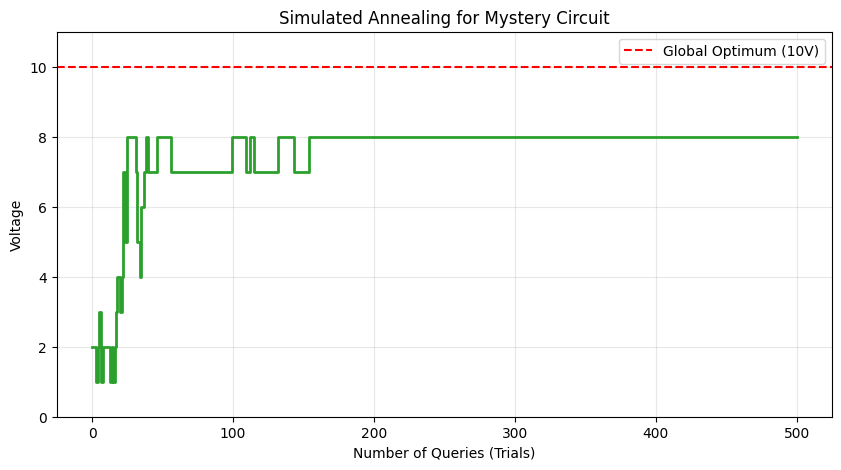

In [ ]:
_, history_sa = simulated_annealing(my_circuit)
optimization_visualizer(history_sa, "Simulated Annealing")

## 2.3 Surrogate model-based optimization
Instead of clicking switches randomly, we can use our past trials to create a simplified representation of the complex black-box function. This representation is called a surrogate model. It allows us to predict the voltage of configurations we haven't even tried yet.

The algorithm iteratively optimizes a black-box function $F(x)$ in a following way:
- Train a surrogate model $\tilde{f}(x)$ using observed data $\{x_i, y_i\}_{i=1,\dots, K}$
- Build an acquisition function $a(x)$ that indicates a candidate configuration.
- Optimize the acquisiton function by an optimization solver i.e. $x_\mathrm{new} = \mathrm{argmin}\ a(x)$.
- Evaluate the output using the optimal configuration i.e. $y_\mathrm{new} = F(x_\mathrm{new})$.
- Add the evaluation to the dataset $\{x_i, y_i\}_{i=1,\dots, K+1}$

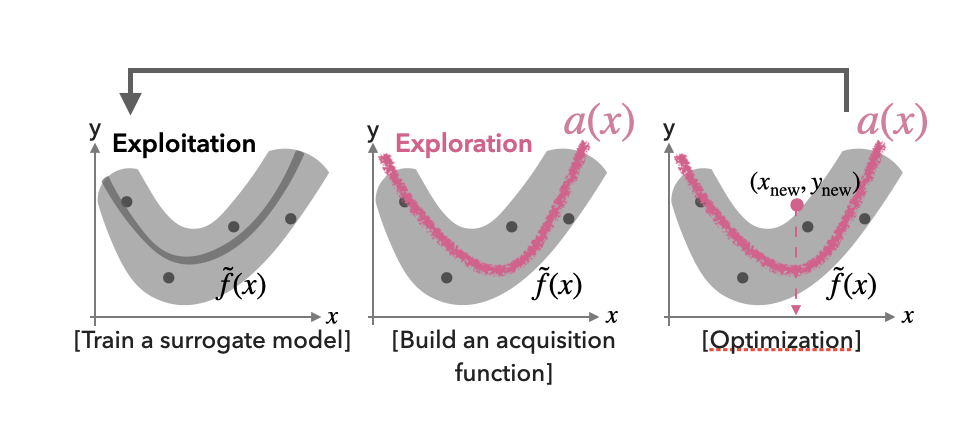

### Exploration vs. Exploitation
A key challenge in optimization is balancing two competing goals:

- Exploitation: Searching in areas where the model predicts a high voltage (targeting known peaks).
- Exploration: Searching in areas where the model is uncertain (investigating unknown territory).

To achieve this exploration behavior, we treat the model's parameters as random variables rather than fixed numbers. By sampling from these probability distributions, the model generates various simulated landscapes. This variety encourages the optimizer to try new patterns and "explore" the search space, rather than just repeating the same successful patterns.

### Designing the model
In this notebook, we use quadratic terms (pairwise interactions) to build our surrogate model. We chose this for two reasons:

- Complexity: It is sophisticated enough to capture the "switch dependencies" that make the puzzle hard.
- Compatibility: It fits the native language of the D-Wave's quantum annealer, which is designed to solve quadratic problems.

The D-Wave's quantum annealer technically samples multiple solutions in constant time. This feature will be an advantage in terms of speed when the problem size $N$ is large.

This time, we use Simulated Annealing solver (or Simulated Quantum Annealing solver) provided from [OpenJij](https://www.openjij.org/) to optimize an acquisition function. Let's install the `openjij` package.

In [ ]:
%pip install openjij

In [ ]:
import openjij

In [ ]:
# @title Surrogate model-based optimization (Bayesian regression with a Gaussian prior)
class CombinatorialBayesianSolver:
    def __init__(self, circuit, alpha=0.1, solver=None):
        self.circuit = circuit
        self.n = circuit.n
        self.alpha = alpha # Regularization strength (Gaussian prior)
        self.observed_x = []
        self.observed_y = []
        self.solver = solver

    def _get_features(self, x):
        """Polynomial expansion representing combinatorial interactions (Walsh-like)"""
        features = [1] + list(x) # Constant + first order
        # Second order
        for i, j in combinations(range(self.n), 2):
            features.append(x[i] * x[j])
        return np.array(features)

    def update_posterior(self):
        """Bayesian Linear Regression posterior"""
        X = np.array([self._get_features(x) for x in self.observed_x])
        y = np.array(self.observed_y)

        # Posterior covariance: Sigma = (X^T X + alpha*I)^-1
        features_dim = X.shape[1]
        A = X.T @ X + self.alpha * np.eye(features_dim)
        Cov = np.linalg.inv(A)

        # Posterior mean: mu = Cov @ X^T @ y
        w_hat = Cov @ X.T @ y

        return w_hat, Cov

    def acquisition_function_params(self):
        """Thompson Sampling"""
        w_hat, Cov = self.update_posterior()

        w_sample = np.random.multivariate_normal(w_hat, Cov)

        constant = w_sample[0]
        linear_weights = w_sample[1:self.n+1]
        quad_weights = w_sample[self.n+1:]

        Q = {}
        # Linear terms
        for i in range(self.n):
            Q[(i, i)] = -linear_weights[i]
        # Quadratic terms
        for idx, (i, j) in enumerate(combinations(range(self.n), 2)):
            Q[(i, j)] = -quad_weights[idx]

        return Q

    def suggest_next(self):
        Q = self.acquisition_function_params()
        response = self.solver.sample_qubo(Q)
        next_dict = response.first[0]
        x_next = np.array([x for x in next_dict.values()])
        return x_next

    def run(self, n_init=5, max_iter=200):
        # initialize dataset
        self.observed_x = [np.random.randint(2, size=n_switches) for x in range(n_init)]
        self.observed_y = [self.circuit.get_voltage(x) for x in opt.observed_x]

        for it in range(max_iter):
            x_new = opt.suggest_next()
            self.observed_x.append(x_new)
            self.observed_y.append(self.circuit.get_voltage(x_new))

In [ ]:
#solver = openjij.SASampler()  # Simulated annealing solver
solver = openjij.SQASampler()  # Simulated quantum annealing solver - partially simulated quantum superposition
opt = CombinatorialBayesianSolver(my_circuit, solver=solver)

n_init = 5
max_iter = 100
opt.run(n_init, max_iter)

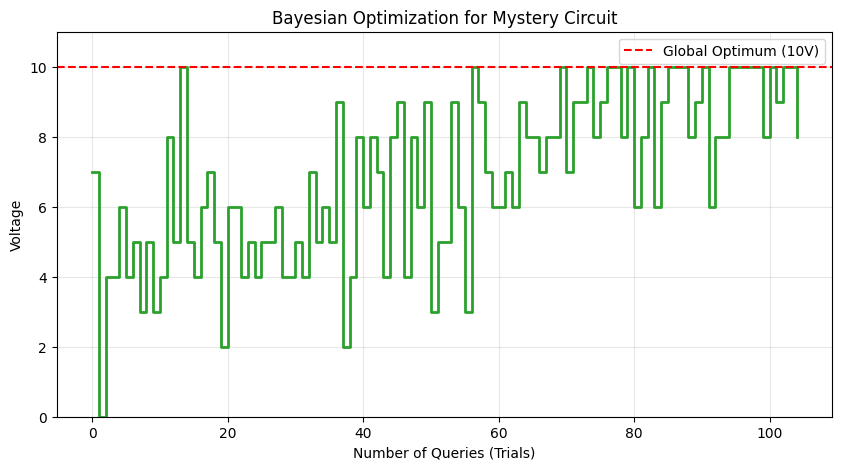

In [ ]:
history_bo = []

for idx, v in enumerate(opt.observed_y):
    history_bo.append((idx, v))
optimization_visualizer(history_bo, "Bayesian Optimization")

# Appendix: NK Landscape
The "Mystery Circuit" used in this notebook is built on a mathematical framework called the NK Landscape. This model is originally developed by biologist Stuart Kauffman to model evolutionary biology and now a standard tool for studying "rugged" optimization problems.

1. What are N and K?
The model uses two parameters to define the "shape" of the search space:
- N (Number of components): In our case, $N=10$ switches. This determines the total size of the landscape ($2^N$ or 1,024 possible combinations).
- K (Degree of interaction): This determines how the switches interacts with each other. It defines how many other switches influence the value of any single switch.

2. How K Controls "Ruggedness"
The value of K determines how hard the problem is to solve:

- $K = 0$ (Smooth Landscape): Each switch is independent. Flipping Switch A never affects the value provided by Switch B. This creates a single, smooth peak. A simple Hill-Climbing strategy will find the maximum perfectly every time.

- $K = 1$ to $2$ (Rugged Landscape): This is what we used ($K=1$). Each switch depends on a neighbor. This creates local optima as we have seen. You must find the right combination of pairs to optimize the output.

- $K = N-1$ (Random Landscape): Every switch depends on every other switch. The landscape becomes totally chaotic and looks like random noise.

In [ ]:
# @title Black-box function used in this notebook

# Here we use the NK landscape model (cf. https://doi.org/10.1186/s41469-018-0039-0)
class MysteryCircuit:
    def __init__(self, n=10, k=2, seed=None):
        self.n = n
        self.k = k
        self._rng = np.random.default_rng(seed=seed)
        self._raw_min = 1000

        # 1. Generate random tables
        self.tables = []
        for i in range(n):
            table = {bits: self._rng.uniform(0, 1) for bits in product([0, 1], repeat=k+1)}
            self.tables.append(table)

        # 2. Brute force to find max and the best configuration
        self._raw_max, self.best_config = self._find_global_optimum()

    def _find_global_optimum(self):
        max_score = -1
        min_score = 1000
        best_c = None

        for config in product([0, 1], repeat=self.n):
            current_score = self._calculate_raw(config)
            if current_score > max_score:
                max_score = current_score
                best_c = config
            if current_score < min_score:
                min_score = current_score

        self._raw_min = min_score
        # Return the max value and the config as a readable string
        return max_score, "".join(map(str, best_c))

    def _calculate_raw(self, switches):
        score = 0
        for i in range(self.n):
            sub_config = tuple(switches[(i + j) % self.n] for j in range(self.k + 1))
            score += self.tables[i][sub_config]
        return score

    def get_voltage(self, switches):
        raw = self._calculate_raw(switches)
        bias = self._raw_min
        factor = self._raw_max - self._raw_min
        return int(round(((raw - bias) / factor) * 10, 2))